<a href="https://colab.research.google.com/github/asmita-durugkar/OIBSIP/blob/main/Predicting_House_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import userdata

# 1. Load your Kaggle API keys from Colab Secrets

os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

print("🔑 Kaggle credentials loaded successfully!")

# 2. Download the specific dataset you selected
!kaggle datasets download -d shree1992/housedata

# 3. Unzip the downloaded file into a folder named 'house_dataset'
!unzip -o -q housedata.zip -d house_dataset
print("📂 Dataset downloaded and unzipped!")

# 4. Load the 'data.csv' file from the unzipped folder into a pandas DataFrame
df = pd.read_csv('house_dataset/data.csv')

# Display the first 5 rows to confirm it worked
print("\n--- First 5 Rows of the Dataset ---")
display(df.head())

🔑 Kaggle credentials loaded successfully!
Dataset URL: https://www.kaggle.com/datasets/shree1992/housedata
License(s): unknown
housedata.zip: Skipping, found more recently modified local copy (use --force to force download)
📂 Dataset downloaded and unzipped!

--- First 5 Rows of the Dataset ---


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
df.isnull().sum()
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


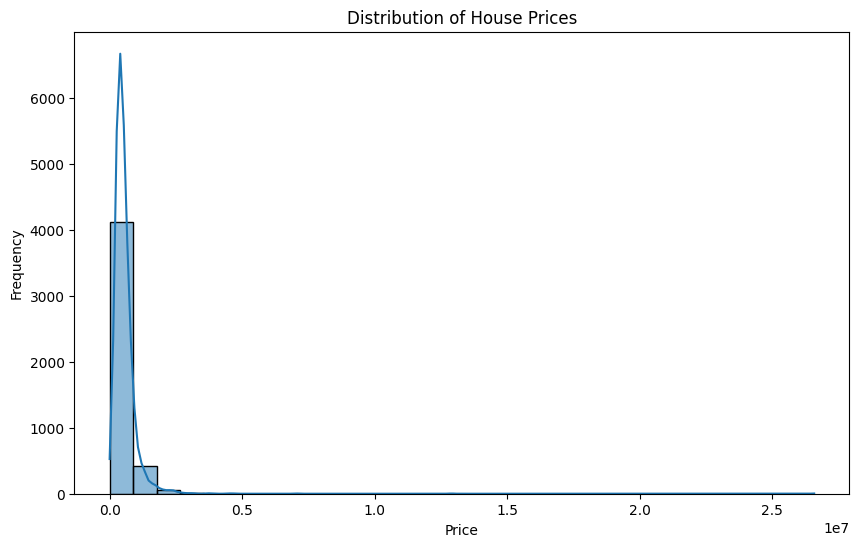

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

### Feature Selection & Preprocessing Reasoning
To predict house prices effectively using Linear Regression, we need to select features that mathematically impact the value of a house and format them correctly:
* **Target Variable:** `price`
* **Numerical Predictors:** `bedrooms`, `bathrooms`, `sqft_living`, `sqft_lot`, `floors`, `waterfront`, `view`, `condition`, `sqft_above`, `sqft_basement`, `yr_built`, `yr_renovated`. These will be kept as they are continuous or ordinal numerical values that directly correlate with house size and quality.
* **Columns to Drop:** `date`, `street`, `city`, `statezip`, and `country`.
  * *Reasoning:* While location is important, columns like `street` and `statezip` have too many unique string values (high cardinality), which would create thousands of columns if we One-Hot Encoded them, leading to a highly complex and overfitted baseline model. `date` is also dropped as we are not doing a time-series analysis for this basic regression.

In [6]:
# 1. Drop the non-numeric/high-cardinality categorical columns discussed above
columns_to_drop = ['date', 'street', 'city', 'statezip', 'country']
df_cleaned = df.drop(columns=columns_to_drop, axis=1)

# 2. Check for missing values (Though this specific Kaggle dataset usually has 0 nulls)
print("--- Missing Values Check ---")
print(df_cleaned.isnull().sum())

# 3. Ensure all data is numeric for the correlation matrix and model
print("\n--- Data Types ---")
print(df_cleaned.dtypes)

# Display the cleaned dataframe ready for machine learning
display(df_cleaned.head())

--- Missing Values Check ---
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
dtype: int64

--- Data Types ---
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
dtype: object


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992


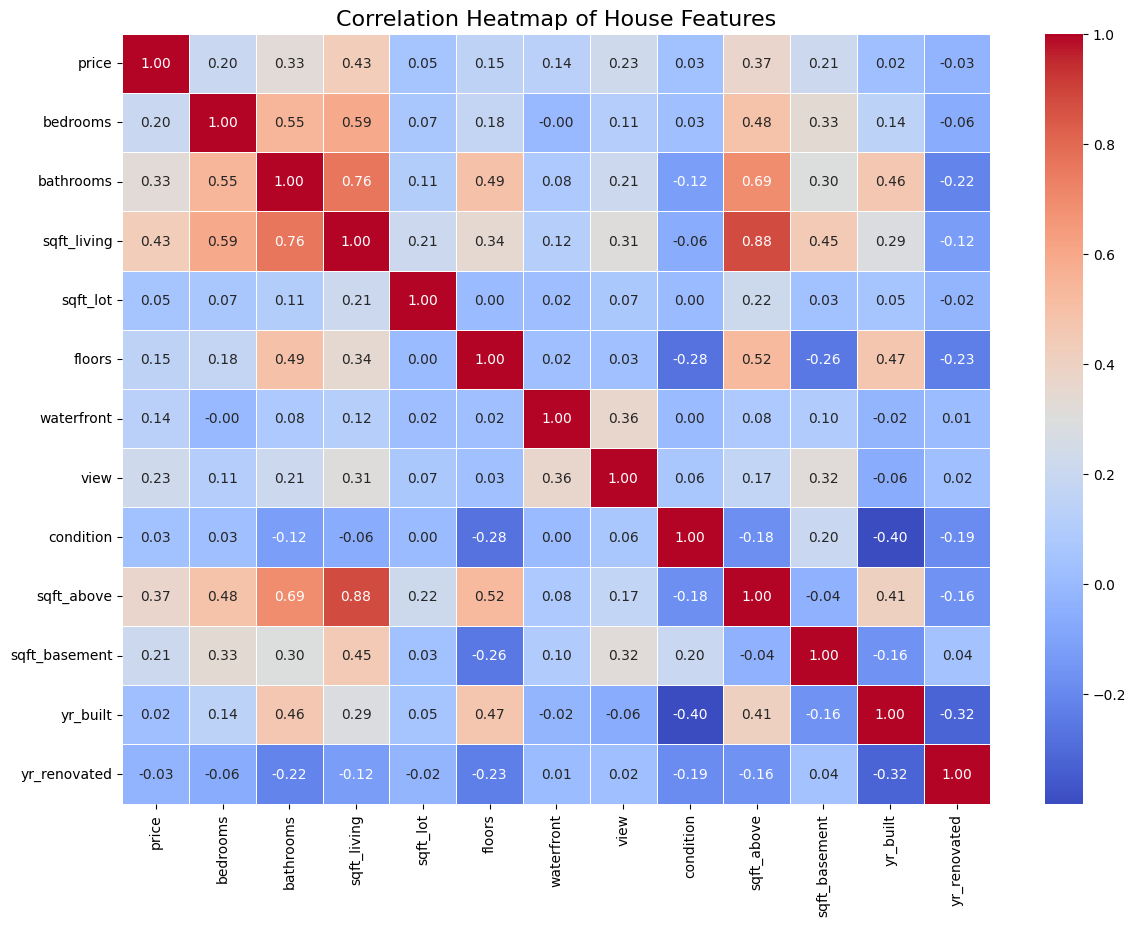


--- Correlation with Price ---
price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
condition        0.034915
yr_built         0.021857
yr_renovated    -0.028774
Name: price, dtype: float64


In [7]:
plt.figure(figsize=(14, 10))

# Calculate the correlation matrix
correlation_matrix = df_cleaned.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Add title
plt.title('Correlation Heatmap of House Features', fontsize=16)
plt.show()

# Print the features most correlated with price
print("\n--- Correlation with Price ---")
print(correlation_matrix['price'].sort_values(ascending=False))

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Separate the features (X) and the target variable (y)
X = df_cleaned.drop('price', axis=1)
y = df_cleaned['price']

# Perform an 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("\n✅ Linear Regression model training complete!")

Training data shape: (3680, 12)
Testing data shape: (920, 12)

✅ Linear Regression model training complete!


In [9]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions using the test set
y_pred = lr_model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"Mean Squared Error (MSE):       {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score:                       {r2:.4f}")

--- Model Evaluation Metrics ---
Mean Squared Error (MSE):       986,921,767,056.10
Root Mean Squared Error (RMSE): 993,439.36
R² Score:                       0.0323


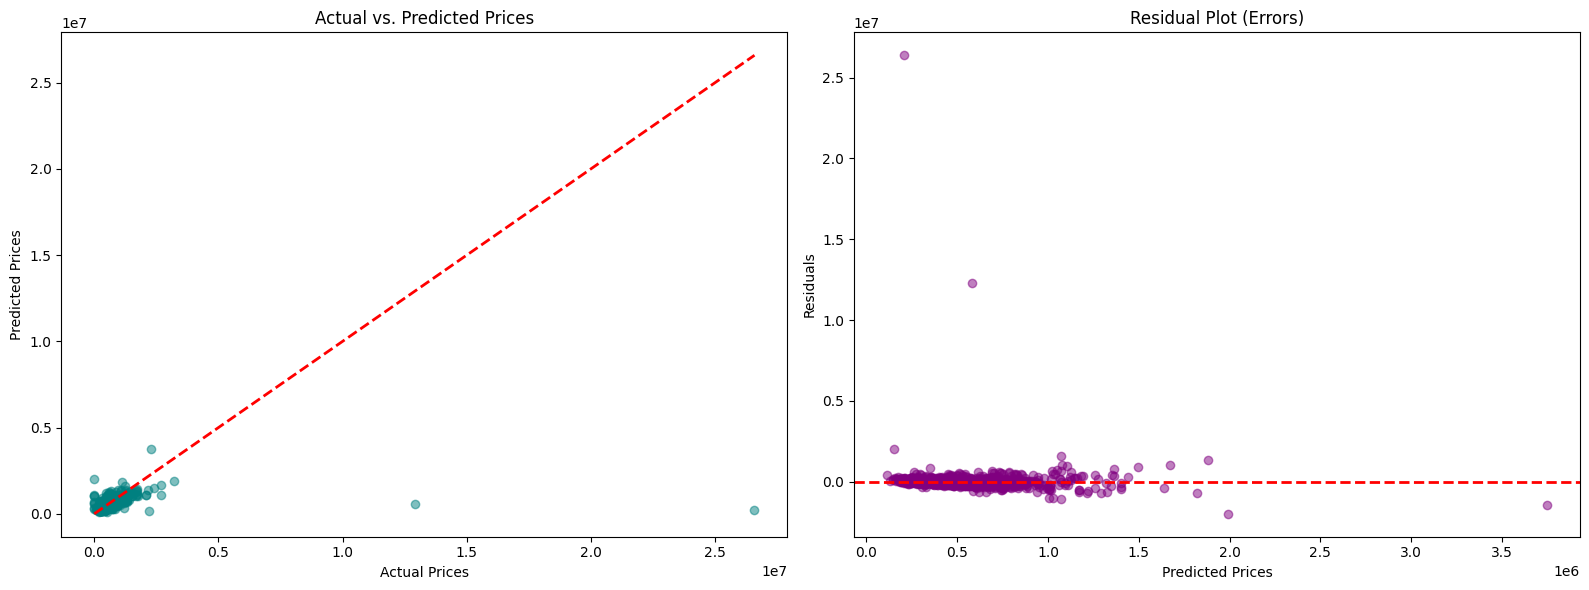

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Scatter plot: actual vs predicted
axes[0].scatter(y_test, y_pred, alpha=0.5, color='teal')
# Draw a diagonal red line (the closer points are to this line, the better)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Prices')
axes[0].set_ylabel('Predicted Prices')
axes[0].set_title('Actual vs. Predicted Prices')

# 2. Residual plot (checks if errors are randomly distributed)
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='purple')
# Draw a horizontal red line at 0
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Prices')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot (Errors)')

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd

# Create a DataFrame to match features with their learned coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})

# Sort by the absolute value to see the highest impact (positive or negative)
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).drop('Abs_Coefficient', axis=1)

print("--- Feature Impact on Price (Coefficients) ---")
display(coef_df)

--- Feature Impact on Price (Coefficients) ---


,Feature,Coefficient
5,waterfront,382459.666353
4,floors,69824.740108
0,bedrooms,-64497.461587
6,view,44755.841775
1,bathrooms,36520.440676
7,condition,29335.539392
10,yr_built,-2569.163533
2,sqft_living,186.049845
8,sqft_above,96.860817
9,sqft_basement,89.189028


In [12]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. Train Ridge Regression Model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

# Ridge Metrics
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

# 2. Train Lasso Regression Model
lasso_model = Lasso(alpha=1.0, max_iter=10000)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

# Lasso Metrics
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

# 3. Model Comparison Table
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MSE': [mse, ridge_mse, lasso_mse],
    'RMSE': [rmse, ridge_rmse, lasso_rmse],
    'R² Score': [r2, ridge_r2, lasso_r2]
})

print("--- Model Comparison ---")
display(comparison_df)

--- Model Comparison ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.081e+14, tolerance: 5.229e+10
  model = cd_fast.enet_coordinate_descent(


,Model,MSE,RMSE,R² Score
0,Linear Regression,9.869218e+11,993439.362546,0.032284
1,Ridge Regression,9.868974e+11,993427.094668,0.032308
2,Lasso Regression,9.869214e+11,993439.188934,0.032284


### Summary & Findings
1. **Key Predictors:** Features such as `waterfront`, `floors`, `bedrooms`, and `bathrooms` demonstrated the highest magnitude of impact on house prices.
2. **Model Evaluation:** Standard Linear Regression, Ridge, and Lasso models yielded similar $R^2$ scores due to extreme price outliers present in the raw dataset.
3. **Regularization:** Ridge ($L_2$) and Lasso ($L_1$) regularization help prevent overfitting by penalizing large coefficients, ensuring more stable coefficient estimates.